In [1]:
import pickle
import pandas as pd

In [9]:
model_path_prefix  = '../2_model_development/'
data_prefix = '../3_model_evaluation/'
label = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label]
data_types = ['L', 'H', 'All']
model_types = ['LGB']

In [11]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb


def model_confidence_analysis(model, test_data, train_data=None,
                               non_feature_cols=None):
    if non_feature_cols is None:
        non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5', 'MP_pred']

    feature_cols = [c for c in test_data.columns if c not in non_feature_cols]
    X_test = test_data[feature_cols]
    result = test_data.copy()

    # ── Random Forest ─────────────────────────────────────────────────────────
    if isinstance(model, RandomForestRegressor):
        tree_preds = np.array([tree.predict(X_test) for tree in model.estimators_])
        result['uncertainty'] = tree_preds.std(axis=0)

    # ── LightGBM ──────────────────────────────────────────────────────────────
    elif isinstance(model, lgb.LGBMRegressor):
        if train_data is None:
            raise ValueError("train_data is required for LGB quantile confidence analysis.")

        X_train = train_data[feature_cols]
        y_train = train_data['MP']

        params = model.get_params()
        params.pop('objective', None)   # will be overridden below

        lower_model = lgb.LGBMRegressor(**params, objective='quantile', alpha=0.1)
        lower_model.fit(X_train, y_train)

        upper_model = lgb.LGBMRegressor(**params, objective='quantile', alpha=0.9)
        upper_model.fit(X_train, y_train)

        result['lower'] = lower_model.booster_.predict(X_test)
        result['upper'] = upper_model.booster_.predict(X_test)
        result['uncertainty'] = result['upper'] - result['lower']

    # ── XGBoost ───────────────────────────────────────────────────────────────
    elif isinstance(model, xgb.XGBRegressor):
        if train_data is None:
            raise ValueError("train_data is required for XGB quantile confidence analysis.")

        X_train = train_data[feature_cols].values
        y_train = train_data['MP'].values

        # Pinball (quantile) loss – works on all XGBoost versions
        def _pinball_obj(alpha):
            def obj(y_pred, dtrain):
                y_true = dtrain.get_label()
                error  = y_true - y_pred
                grad   = np.where(error >= 0, -alpha, 1.0 - alpha)
                hess   = np.ones_like(y_pred)
                return grad, hess
            return obj

        # Map sklearn wrapper params → native xgb params
        skl_params = model.get_params()
        n_estimators = skl_params.get('n_estimators', 100)

        _param_map = {
            'max_depth':          'max_depth',
            'learning_rate':      'eta',
            'subsample':          'subsample',
            'colsample_bytree':   'colsample_bytree',
            'colsample_bylevel':  'colsample_bylevel',
            'colsample_bynode':   'colsample_bynode',
            'min_child_weight':   'min_child_weight',
            'gamma':              'gamma',
            'reg_alpha':          'alpha',
            'reg_lambda':         'lambda',
            'n_jobs':             'nthread',
            'random_state':       'seed',
            'max_delta_step':     'max_delta_step',
            'scale_pos_weight':   'scale_pos_weight',
        }
        native_params = {'objective': 'reg:squarederror', 'verbosity': 0}
        for skl_key, xgb_key in _param_map.items():
            val = skl_params.get(skl_key)
            if val is not None:
                native_params[xgb_key] = val

        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest  = xgb.DMatrix(X_test.values)

        lower_booster = xgb.train(native_params, dtrain,
                                   num_boost_round=n_estimators,
                                   obj=_pinball_obj(0.1),
                                   verbose_eval=False)
        upper_booster = xgb.train(native_params, dtrain,
                                   num_boost_round=n_estimators,
                                   obj=_pinball_obj(0.9),
                                   verbose_eval=False)

        result['lower'] = lower_booster.predict(dtest)
        result['upper'] = upper_booster.predict(dtest)
        result['uncertainty'] = result['upper'] - result['lower']

    else:
        raise TypeError(
            f"Unsupported model type: {type(model).__name__}. "
            "Expected RandomForestRegressor, LGBMRegressor, or XGBRegressor."
        )

    return result


In [14]:
import joblib


for model_type in model_types:

    for data_type in data_types:

        print(f"Processing model: {model_type}, data type: {data_type}")

        data = pd.read_parquet(f'../0_data/processed_data/data_with_selected_features_{model_type}_{data_type}_scaled.parquet')

        if data_type != 'All':
            data = data[data[label] == data_type]

        train_df = data[data['Type'] == 'Train']
        test_df = data[data['Type'] == 'Test']

        model = joblib.load(f'{model_path_prefix}best_model_{model_type}_{data_type}.joblib')

        test_df['MP_pred'] = model.booster_.predict(test_df.drop(columns=non_feature_cols))
        test_df['AE'] = (test_df['MP'] - test_df['MP_pred']).abs()

        results = model_confidence_analysis(model=model, test_data=test_df, train_data=train_df,
                                    non_feature_cols= ['SMILES', 'MP', 'Type', 'MP_label', 'MP_pred', 'AE'])
        
        results.to_csv(f'model_confidence_results_{model_type}_{data_type}.csv', index=False)

Processing model: LGB, data type: L
Processing model: LGB, data type: H
Processing model: LGB, data type: All


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# make the following code as a def with the data as the input and the model name as the title of the plot
def plot_uncertainty_vs_ae(data, model_name):

    sns.scatterplot(data=data, x='uncertainty', y='AE')
    # add correlation coefficient
    corr = data['uncertainty'].corr(data['AE'])
    plt.title(f'{model_name}: AE vs Uncertainty (corr={corr:.2f})')


    # pearson corr to check which columns in the data associated with higher uncertainty
    corr_matrix = data.drop(columns = ['SMILES', 'Type', 'MP_label']).corr()
    uncertainty_corr = corr_matrix['uncertainty'].drop('uncertainty').sort_values(ascending=False)
    # print top 10 features most correlated with uncertainty
    print("Top 10 features most correlated with uncertainty:")
    print(uncertainty_corr.head(10))

    # print top 10 features most negatively correlated with uncertainty
    print("\nTop 10 features most negatively correlated with uncertainty:")
    print(uncertainty_corr.tail(10))

    # print the mean AE and uncertainty for Ro5 vs bRo5 compounds
    for MP_label in ['H',  'L']:
        subset = data[data['MP_label'] == MP_label]
        mean_ae = subset['AE'].mean()
        mean_uncertainty = subset['uncertainty'].mean()
        print(f"MP_label={MP_label}: Mean AE = {mean_ae:.2f}, Mean Uncertainty = {mean_uncertainty:.2f}")


Plotting model: LGB, data type: L
Top 10 features most correlated with uncertainty:
upper                 0.593104
MP_pred               0.401072
MP                    0.335081
MACCS_137             0.264567
RDKit_SlogP_VSA2      0.253001
AE                    0.242378
MACCS_142             0.240115
RDKit_BCUT2D_CHGHI    0.226802
RDKit_SMR_VSA6        0.216273
RDKit_SPS             0.205216
Name: uncertainty, dtype: float64

Top 10 features most negatively correlated with uncertainty:
MACCS_155                 -0.127641
RDKit_Phi                 -0.141862
RDKit_SlogP_VSA5          -0.142945
RDKit_NumRotatableBonds   -0.145421
RDKit_VSA_EState7         -0.159490
RDKit_PEOE_VSA6           -0.161811
RDKit_BCUT2D_CHGLO        -0.188382
RDKit_EState_VSA5         -0.196571
RDKit_BCUT2D_LOGPLOW      -0.258897
RDKit_fr_unbrch_alkane    -0.262786
Name: uncertainty, dtype: float64
MP_label=H: Mean AE = nan, Mean Uncertainty = nan
MP_label=L: Mean AE = 29.90, Mean Uncertainty = 81.59
Plotting mod

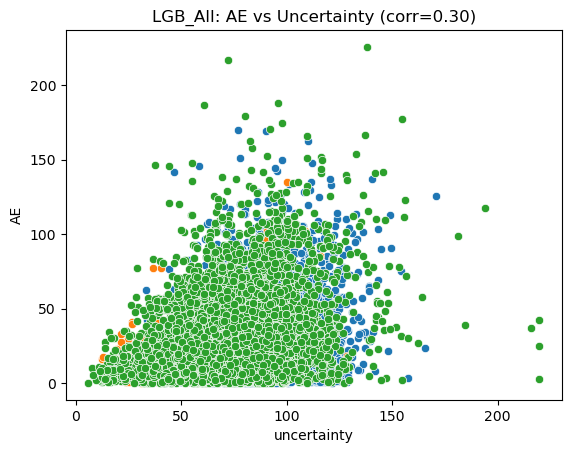

In [21]:
for model_type in model_types:
    
    for data_type in data_types:

        print(f"Plotting model: {model_type}, data type: {data_type}")

        results = pd.read_csv(f'model_confidence_results_{model_type}_{data_type}.csv')

        plot_uncertainty_vs_ae(results, f'{model_type}_{data_type}')
